In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import boto3
import sagemaker
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text
import zarr
import s3fs
import cv2 as cv
from utils import *
from itertools import chain
from math import hypot

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


In [2]:
%store -r
%store

Stored variables and their in-db values:
default_bucket                -> 'sagemaker-us-east-1-298748835671'
s3_project_prefix             -> 's3://sagemaker-us-east-1-298748835671/floorplan-g
s3_project_root               -> 'floorplan-generator'


# Creating Athena Database

In [3]:
sns.set_theme()

sess = sagemaker.Session()
bucket = sess.default_bucket()
role = sagemaker.get_execution_role()
region = boto3.Session().region_name
s3 = boto3.client("s3")

In [4]:
database_name = "room_metadata"
raw_dicts_table = "raw_dicts"
s3_project_prefix = f"s3://{default_bucket}/{s3_project_root}"

s3_staging_dir = f"{s3_project_prefix}/athena/staging/"

engine = create_engine(
    f"awsathena+rest://@athena.{region}.amazonaws.com:443/"
    f"{database_name}"
    f"?s3_staging_dir={s3_staging_dir}"
)

In [5]:
%store s3_project_prefix

Stored 's3_project_prefix' (str)


In [6]:
#s3.download_file(default_bucket, "floorplan-generator/metadata/metadata.parquet", "metadata.parquet")

In [6]:
metadata_df = pd.read_parquet("metadata.parquet")
metadata_df.shape

(700, 10)

In [7]:
metadata_df.tail()

,sample_id,0,1,2,3,4,5,6,7,id
695,sample_00695,"{'category': 2, 'centroid': [53, 112]}","{'category': 7, 'centroid': [63, 167]}","{'category': 3, 'centroid': [81, 73]}","{'category': 0, 'centroid': [134, 108]}","{'category': 7.0, 'centroid': [110, 167]}","{'category': 1.0, 'centroid': [182, 168]}","{'category': 3.0, 'centroid': [145, 181]}","{'category': 9.0, 'centroid': [207, 112]}",10771.pkl
696,sample_00696,"{'category': 7, 'centroid': [69, 95]}","{'category': 3, 'centroid': [69, 135]}","{'category': 0, 'centroid': [119, 168]}","{'category': 2, 'centroid': [69, 185]}","{'category': 1.0, 'centroid': [121, 79]}","{'category': 7.0, 'centroid': [129, 126]}","{'category': 9.0, 'centroid': [188, 175]}",None,10774.pkl
697,sample_00697,"{'category': 2, 'centroid': [47, 145]}","{'category': 7, 'centroid': [68, 101]}","{'category': 0, 'centroid': [119, 154]}","{'category': 3, 'centroid': [100, 91]}","{'category': 9.0, 'centroid': [137, 100]}","{'category': 1.0, 'centroid': [187, 100]}","{'category': 9.0, 'centroid': [192, 155]}","{'category': 9.0, 'centroid': [220, 100]}",10775.pkl
698,sample_00698,"{'category': 9, 'centroid': [66, 128]}","{'category': 2, 'centroid': [66, 161]}","{'category': 0, 'centroid': [126, 169]}","{'category': 3, 'centroid': [102, 129]}","{'category': 1.0, 'centroid': [151, 77]}","{'category': 7.0, 'centroid': [159, 120]}","{'category': 9.0, 'centroid': [195, 172]}",None,10776.pkl
699,sample_00699,"{'category': 9, 'centroid': [62, 176]}","{'category': 1, 'centroid': [105, 77]}","{'category': 7, 'centroid': [105, 124]}","{'category': 0, 'centroid': [131, 165]}","{'category': 7.0, 'centroid': [155, 67]}","{'category': 3.0, 'centroid': [164, 105]}","{'category': 9.0, 'centroid': [192, 104]}","{'category': 2.0, 'centroid': [191, 148]}",10777.pkl


s3://sagemaker-us-east-1-298748835671/floorplan-generator/metadata/metadata.parquet

# Visualizing All Layers Stacked

In [9]:
# Get room vocab
vocab = get_vocab()
room_index = vocab["object_idx_to_name"]

# Open the S3 filesystem
fs = s3fs.S3FileSystem()

# Open the zarr store
store = s3fs.S3Map(root=f'{s3_project_prefix}/store/data.zarr', s3=fs, check=False)

# Open the zarr array or group
z = zarr.open(store, mode='r')

# Load sample
boundary_mask = z['boundary_masks'][30]
inside_mask = z['inside_masks'][30]
room_mask = z['room_masks'][30]
door_mask = z['door_masks'][30]
edge_totals = z['edge_totals'][30]
edge_index = z['edge_index'][30]
edge_attr = z['edge_attr'][30]
node_features = z['node_features'][30]
node_labels = z['node_labels'][30]
node_totals = z['node_totals'][30]

metadata = metadata_df.iloc[30, 1:-1]

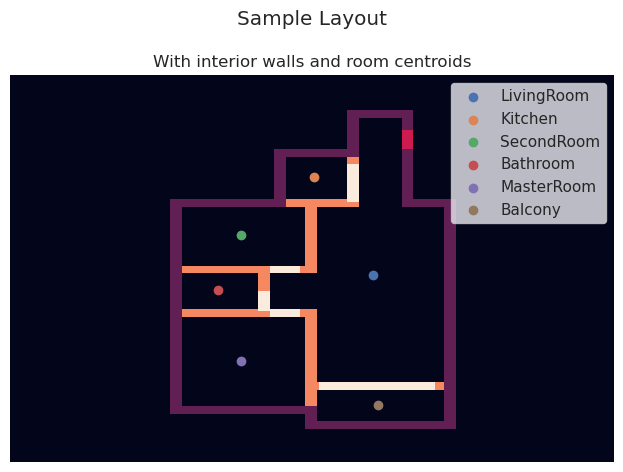

In [13]:
# recovering walls through elementise addition
fig, ax = plt.subplots()

stacked_layers = stack_normalize(boundary_mask, room_mask, door_mask)
sns.heatmap(stacked_layers, 
            cbar=False, xticklabels=False, yticklabels=False)

for room in metadata:
    if room:
        ax.scatter(
            room["centroid"][1], 
            room["centroid"][0],
            label=room_index[int(room["category"])]
            )

ax.set_title("With interior walls and room centroids")
ax.legend()

plt.suptitle("Sample Layout")
plt.tight_layout()
plt.show()

# Visualizing Individual Masks (Channels)

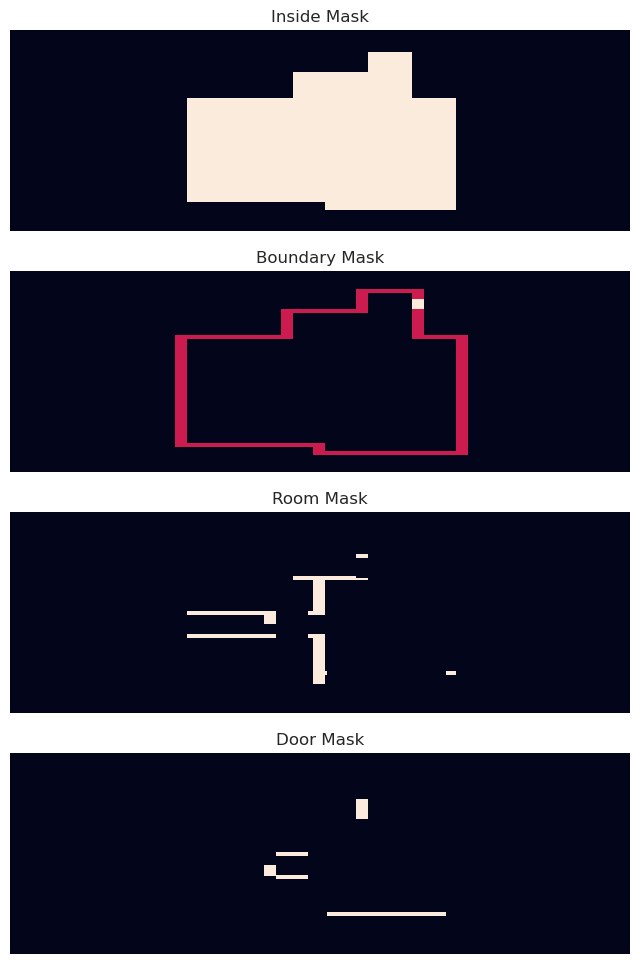

In [14]:
masks = [inside_mask, boundary_mask, room_mask, door_mask]

fig, ax = plt.subplots(len(masks), figsize=(8, 12))

for i, mask in enumerate(masks):
    sns.heatmap(mask, ax=ax[i], cbar=False, xticklabels=False, yticklabels=False)

ax[0].set_title("Inside Mask")
ax[1].set_title("Boundary Mask")
ax[2].set_title("Room Mask")
ax[3].set_title("Door Mask")

plt.show()

# Graph Extraction

<Axes: >

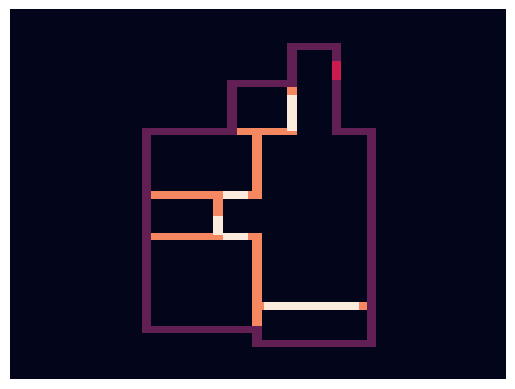

In [15]:
sns.heatmap(stacked_layers, xticklabels=False, yticklabels=False, cbar=False)

In [16]:
np.unique(stacked_layers)

array([0, 1, 2, 3, 4], dtype=uint64)

<Axes: >

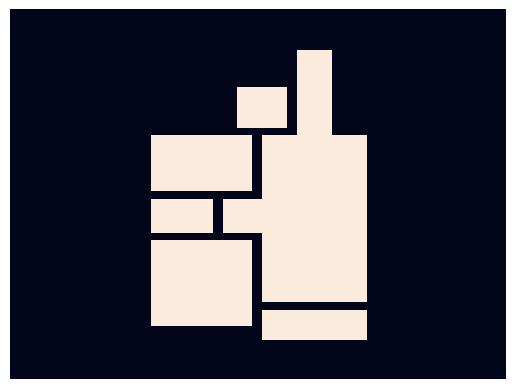

In [17]:
stacked_layers_bin = stack_binarize(stacked_layers)
negative_space = negative_space(stacked_layers_bin, inside_mask)

sns.heatmap(negative_space, xticklabels=False, yticklabels=False, cbar=False)

In [18]:
num_labels, labels, stats, centroids = conn_components(inside_mask, 
                                                       boundary_mask, 
                                                       room_mask, 
                                                       door_mask)

num_labels

7

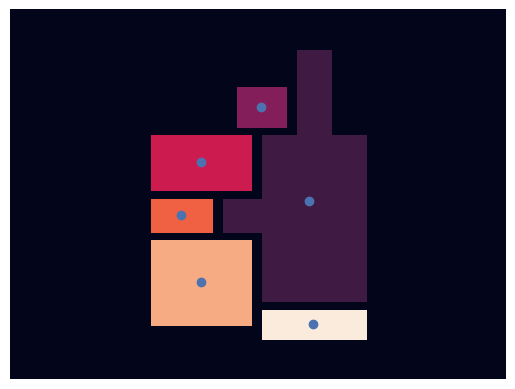

In [19]:
fig, ax = plt.subplots()

sns.heatmap(labels, xticklabels=False, yticklabels=False, cbar=False, ax=ax)
ax.scatter(centroids[1:,0], centroids[1:,1])

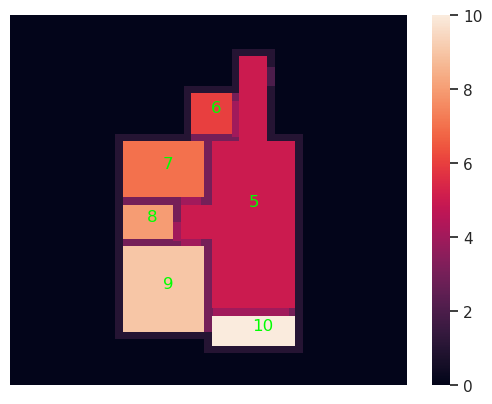

In [20]:
fig, ax = plt.subplots()

rwb = rooms_with_bounds(stacked_layers, labels)

sns.heatmap(rwb, xticklabels=False, yticklabels=False, cbar=True, ax=ax)

for i, centroid in enumerate(centroids[1:, :]):
    ax.text(centroid[0], centroid[1], f"{i+5}", color="lime")

In [21]:
centroids.shape

(7, 2)

In [22]:
stats_cols = ["left", "top", "width", "height", "area"]
pd.DataFrame(stats, columns=stats_cols)

,left,top,width,height,area
0,0,0,256,256,50004
1,110,28,74,175,7806
2,117,54,26,28,728
3,73,87,52,39,2028
4,73,131,32,24,768
5,73,160,52,59,3068
6,130,208,54,21,1134


In [23]:
adj_graph = extract_all_adjacencies(rwb)
adj_graph

,n1,n2,adj_type,edge_strength
0,5,6,0,11
1,5,6,1,23
2,5,7,0,41
3,5,7,1,7
4,5,8,0,12
5,5,8,1,12
6,5,9,0,45
7,5,9,1,7
8,5,10,0,5
9,5,10,1,37


In [24]:
src, dst, attrs = [], [], []
for e in adj_graph.iterrows():
    row = e[1]
    for u, v in [(row["n1"], row["n2"]), (row["n2"], row["n1"])]:
        src.append(u)
        dst.append(v)
        attrs.append([row["adj_type"], float(row["edge_strength"])])

In [25]:
print(src)
print(dst)
print(attrs)

[np.int64(5), np.int64(6), np.int64(5), np.int64(6), np.int64(5), np.int64(7), np.int64(5), np.int64(7), np.int64(5), np.int64(8), np.int64(5), np.int64(8), np.int64(5), np.int64(9), np.int64(5), np.int64(9), np.int64(5), np.int64(10), np.int64(5), np.int64(10), np.int64(6), np.int64(7), np.int64(7), np.int64(8), np.int64(8), np.int64(9), np.int64(9), np.int64(10)]
[np.int64(6), np.int64(5), np.int64(6), np.int64(5), np.int64(7), np.int64(5), np.int64(7), np.int64(5), np.int64(8), np.int64(5), np.int64(8), np.int64(5), np.int64(9), np.int64(5), np.int64(9), np.int64(5), np.int64(10), np.int64(5), np.int64(10), np.int64(5), np.int64(7), np.int64(6), np.int64(8), np.int64(7), np.int64(9), np.int64(8), np.int64(10), np.int64(9)]
[[np.int64(0), 11.0], [np.int64(0), 11.0], [np.int64(1), 23.0], [np.int64(1), 23.0], [np.int64(0), 41.0], [np.int64(0), 41.0], [np.int64(1), 7.0], [np.int64(1), 7.0], [np.int64(0), 12.0], [np.int64(0), 12.0], [np.int64(1), 12.0], [np.int64(1), 12.0], [np.int64(0),

In [26]:
metadata

0      {'category': 0, 'centroid': [132, 154]}
1       {'category': 2, 'centroid': [67, 129]}
2       {'category': 7, 'centroid': [106, 98]}
3       {'category': 3, 'centroid': [142, 88]}
4     {'category': 1.0, 'centroid': [189, 98]}
5    {'category': 9.0, 'centroid': [218, 156]}
6                                         None
7                                         None
Name: 30, dtype: object

In [27]:
centroids[1:, :].round()

array([[154., 132.],
       [130.,  68.],
       [ 98., 106.],
       [ 88., 142.],
       [ 98., 189.],
       [156., 218.]])

In [36]:
categories = join_meta_category(centroids[1:, :], metadata)

/home/sagemaker-user/Generative-Interior-Synthesis/utils.py:155: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  categories.append(int(metadata_row[np.argmin(dists)]["category"]))


In [37]:
categories

[0, 2, 7, 3, 1, 9]

In [33]:
node_totals

array([6])

In [34]:
node_features

array([[ 154.22482706,  132.4727133 , 7806.        ],
       [ 129.5       ,   67.5       ,  728.        ],
       [  98.5       ,  106.        , 2028.        ],
       [  88.5       ,  142.5       ,  768.        ],
       [  98.5       ,  189.        , 3068.        ],
       [ 156.5       ,  218.        , 1134.        ],
       [   0.        ,    0.        ,    0.        ],
       [   0.        ,    0.        ,    0.        ],
       [   0.        ,    0.        ,    0.        ],
       [   0.        ,    0.        ,    0.        ],
       [   0.        ,    0.        ,    0.        ],
       [   0.        ,    0.        ,    0.        ],
       [   0.        ,    0.        ,    0.        ],
       [   0.        ,    0.        ,    0.        ],
       [   0.        ,    0.        ,    0.        ],
       [   0.        ,    0.        ,    0.        ],
       [   0.        ,    0.        ,    0.        ],
       [   0.        ,    0.        ,    0.        ],
       [   0.        ,    0.

In [35]:
node_labels

array([ 0,  2,  7,  3,  1,  9, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1])

In [38]:
edge_totals

array([28])

In [39]:
edge_index

array([[ 5,  6,  5,  6,  5,  7,  5,  7,  5,  8,  5,  8,  5,  9,  5,  9,
         5, 10,  5, 10,  6,  7,  7,  8,  8,  9,  9, 10,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 6,  5,  6,  5,  7,  5,  7,  5,  8,  5,  8,  5,  9,  5,  9,  5,
        10,  5, 10,  5,  7,  6,  8,  7,  9,  8, 10,  9,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0]])